In this notebook, I include baseline models for Linear Regression, Ridge Regression, Random Forest, and XGBoost, along with hyperparameter tuning for Random Forest and XGBoost. The dataset used in this analysis covers the period from July 2025 to February 2026.

In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

In [2]:
from src.Preprocessing import get_preprocessed_data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.


In [3]:
X_train, X_test, y_train, y_test = get_preprocessed_data()

print(X_train.shape)
print(X_test.shape)

Retrieved 74635 rows of data from the database.
Processing 74635 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Finished transforming log(lastPriceByZip).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsTotal.
Found pre-trained imputer model for BathroomsTotalInteger. Returning artifact...
Finished imputation for BathroomsTotalInteger.
Finished impu

In [4]:
X_train.dtypes

Latitude                        float64
Longitude                       float64
PostalCode                      float64
AttachedGarageYN                float64
BathroomsTotalInteger           float64
BedroomsTotal                   float64
FireplaceYN                     float64
GarageSpaces                    float64
LivingArea                      float64
MainLevelBedrooms               float64
NewConstructionYN               float64
ParkingTotal                    float64
PoolPrivateYN                   float64
Stories                         float64
ViewYN                          float64
YearBuilt                       float64
HighSchoolDistrict                 bool
LotSizeArea                     float64
AssociationFee                  float64
CloseDate                datetime64[us]
DaysOnMarket                    float64
sin_closed_date                 float64
cos_closed_date                 float64
log_lastPriceByZip              float64
Flooring_Bamboo                 float64


In [5]:
X_train

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Stone,Flooring_Tile,Flooring_Vinyl,Flooring_Wood,Levels_MultiSplit,Levels_One,Levels_ThreeOrMore,Levels_Two
7472,32.628087,-117.134643,92118.0,0.0,3.0,3.0,1.0,2.0,2968.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7473,32.652310,-117.080299,91910.0,0.0,3.0,6.0,1.0,2.0,3782.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7474,37.260161,-121.984357,95032.0,1.0,2.0,4.0,1.0,2.0,1498.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7475,37.343981,-122.019030,94087.0,1.0,2.0,3.0,1.0,2.0,1528.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7476,39.755692,-121.645678,95969.0,1.0,3.0,3.0,1.0,2.0,2133.0,3.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74619,33.657426,-117.999922,92648.0,0.0,1.0,1.0,0.0,0.0,600.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
74620,39.921866,-122.183747,96021.0,0.0,2.0,3.0,0.0,0.0,1825.0,3.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
74621,33.941069,-116.976432,92223.0,0.0,1.0,2.0,0.0,0.0,876.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
74622,33.305878,-117.190820,92003.0,1.0,5.0,3.0,0.0,4.0,7865.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
X_train["YearBuilt"]

7472     1990.0
7473     1885.0
7474     1964.0
7475     1961.0
7476     1988.0
          ...  
74619    1945.0
74620    1942.0
74621    1947.0
74622    1986.0
74623    1979.0
Name: YearBuilt, Length: 67152, dtype: float64

In [7]:
X_train["LivingArea"]

7472     2968.0
7473     3782.0
7474     1498.0
7475     1528.0
7476     2133.0
          ...  
74619     600.0
74620    1825.0
74621     876.0
74622    7865.0
74623    2603.0
Name: LivingArea, Length: 67152, dtype: float64

In [8]:
X_train["PostalCode"]

7472     92118.0
7473     91910.0
7474     95032.0
7475     94087.0
7476     95969.0
          ...   
74619    92648.0
74620    96021.0
74621    92223.0
74622    92003.0
74623    90077.0
Name: PostalCode, Length: 67152, dtype: float64

In [9]:
X_train["BedroomsTotal"]

7472     3.0
7473     6.0
7474     4.0
7475     3.0
7476     3.0
        ... 
74619    1.0
74620    3.0
74621    2.0
74622    3.0
74623    4.0
Name: BedroomsTotal, Length: 67152, dtype: float64

In [10]:
X_train["BathroomsTotalInteger"]

7472     3.0
7473     3.0
7474     2.0
7475     2.0
7476     3.0
        ... 
74619    1.0
74620    2.0
74621    1.0
74622    5.0
74623    4.0
Name: BathroomsTotalInteger, Length: 67152, dtype: float64

Drop CloseDate and PostalCode to train the models.

In [11]:
X_train_cp = X_train.copy()
X_test_cp = X_test.copy()

In [12]:
drop_cols = ["CloseDate", "PostalCode"]

X_train_cp = X_train_cp.drop(columns=drop_cols)
X_test_cp  = X_test_cp.drop(columns=drop_cols)

(*)Adding new feature only to train the linear model.

In [13]:
X_train_new = X_train_cp.copy()
X_test_new = X_test_cp.copy()
X_train_new["bed_bath_ratio"] = X_train_new["BedroomsTotal"] / (X_train_new["BathroomsTotalInteger"] + 1e-6)
X_test_new["bed_bath_ratio"] = X_test_new["BedroomsTotal"] / (X_test_new["BathroomsTotalInteger"] + 1e-6)

# X_train_new["property_age"] = X_train_new["CloseDate"].dt.year - X_train_new["YearBuilt"]
# X_test_new["property_age"] = X_test_new["CloseDate"].dt.year - X_test_new["YearBuilt"]

# Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lm = LinearRegression()
lm.fit(X_train_cp, y_train)

y_pred = lm.predict(X_test_cp)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.22549517355417203
R2: 0.7961459405469958


(*)Try to fit the new dataset to linear model.

Using X_train_new and X_test_new:

In [16]:
lm = LinearRegression()
lm.fit(X_train_new, y_train)

y_pred = lm.predict(X_test_new)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.2254956266274231
R2: 0.7961451213639261


# Ridge Regression

In [17]:
X_train_rr = X_train.copy().drop(columns="CloseDate")
X_test_rr = X_test.copy().drop(columns="CloseDate")

In [18]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_rr, y_train)

y_pred = ridge.predict(X_test_rr)

ridge.score(X_test_rr, y_test)

r2_ridge = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Ridge R2:", r2_ridge)
print("Ridge RMSE:", rmse)

Ridge R2: 0.7968390066188418
Ridge RMSE: 0.22511152626692857


# Random Forest

In [19]:
X_train_rf = X_train.copy().drop(columns="CloseDate")
X_test_rf = X_test.copy().drop(columns="CloseDate")

(*)RF tuning based on n_estimators and max_depth.

In [20]:
for depth in [15, 20, 30]:
    for n in [100, 200, 300]:

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train_rf, y_train)
        y_pred = rf.predict(X_test_rf)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        train_r2 = rf.score(X_train_rf, y_train)

        print(f"n={n}, depth={depth}")
        print("Train R2:", train_r2)
        print("Test  R2:", r2)
        print("RMSE:", rmse)
        print("---------")

n=100, depth=15
Train R2: 0.9617436452948762
Test  R2: 0.8458933988563619
RMSE: 0.19605963496778536
---------
n=200, depth=15
Train R2: 0.9621211440540646
Test  R2: 0.8467392884486185
RMSE: 0.19552080986129922
---------
n=300, depth=15
Train R2: 0.9622043514738852
Test  R2: 0.8472353853445621
RMSE: 0.19520410805642127
---------
n=100, depth=20
Train R2: 0.9809914149351084
Test  R2: 0.8514996708419607
RMSE: 0.19246035246768992
---------
n=200, depth=20
Train R2: 0.9813853082906513
Test  R2: 0.851993792953494
RMSE: 0.19213988800627485
---------
n=300, depth=20
Train R2: 0.9814691379235904
Test  R2: 0.8525738199486064
RMSE: 0.19176302636526477
---------
n=100, depth=30
Train R2: 0.9850509936618062
Test  R2: 0.851608018774895
RMSE: 0.19239012876357184
---------
n=200, depth=30
Train R2: 0.9854615361205898
Test  R2: 0.8527511047707697
RMSE: 0.19164769101338258
---------
n=300, depth=30
Train R2: 0.98552709162058
Test  R2: 0.8534345716678774
RMSE: 0.19120240006464154
---------


(*)Checking overfitting.

     n  depth    RMSE  Train_R2  Test_R2     Gap
0  100     15  0.1961    0.9617   0.8459  0.1159
1  200     15  0.1955    0.9621   0.8467  0.1154
2  300     15  0.1952    0.9622   0.8472  0.1150
3  100     20  0.1925    0.9810   0.8515  0.1295
4  200     20  0.1921    0.9814   0.8520  0.1294
5  300     20  0.1918    0.9815   0.8526  0.1289
6  100     30  0.1924    0.9851   0.8516  0.1334
7  200     30  0.1916    0.9855   0.8528  0.1327
8  300     30  0.1912    0.9855   0.8534  0.1321


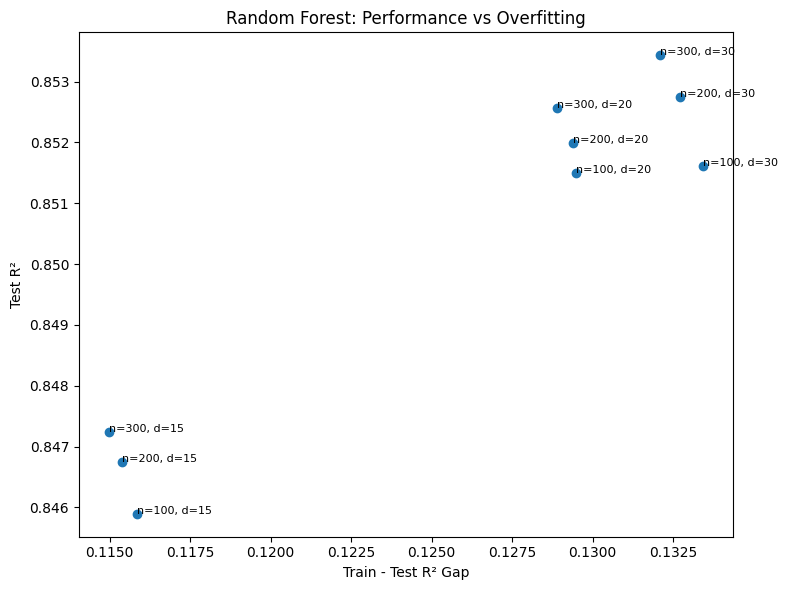

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

rows = [
    {"n": 100, "depth": 15, "RMSE": 0.19605963496778536, "Train_R2": 0.9617436452948762, "Test_R2": 0.8458933988563619},
    {"n": 200, "depth": 15, "RMSE": 0.19552080986129922, "Train_R2": 0.9621211440540646, "Test_R2": 0.8467392884486185},
    {"n": 300, "depth": 15, "RMSE": 0.19520410805642127, "Train_R2": 0.9622043514738852, "Test_R2": 0.8472353853445621},
    
    {"n": 100, "depth": 20, "RMSE": 0.19246035246768992, "Train_R2": 0.9809914149351084, "Test_R2": 0.8514996708419607},
    {"n": 200, "depth": 20, "RMSE": 0.19213988800627485, "Train_R2": 0.9813853082906513, "Test_R2": 0.851993792953494},
    {"n": 300, "depth": 20, "RMSE": 0.19176302636526477, "Train_R2": 0.9814691379235904, "Test_R2": 0.8525738199486064},
    
    {"n": 100, "depth": 30, "RMSE": 0.19239012876357184, "Train_R2": 0.9850509936618062, "Test_R2": 0.851608018774895},
    {"n": 200, "depth": 30, "RMSE": 0.19164769101338258, "Train_R2": 0.9854615361205898, "Test_R2": 0.8527511047707697},
    {"n": 300, "depth": 30, "RMSE": 0.19120240006464154, "Train_R2": 0.98552709162058, "Test_R2": 0.8534345716678774},
]

df = pd.DataFrame(rows)

# Create the overfitting gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

# Print table
print(df.round(4))

# Scatter plot: overfitting vs performance
plt.figure(figsize=(8, 6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}",
        (row["Gap"], row["Test_R2"]),
        fontsize=8
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("Random Forest: Performance vs Overfitting")
plt.tight_layout()
plt.show()

After tuning n_estimators and max_depth, considering the overfitting, 300 trees and depth 20 could be a good model with $R^2$ = 0.8526.

# XGBoost

In [22]:
X_train_xgb = X_train.copy().drop(columns="CloseDate")
X_test_xgb = X_test.copy().drop(columns="CloseDate")

In [23]:
import xgboost as xgb

Baseline mdoel:

In [24]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)
y_pred = xgb_model.predict(X_test_xgb)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.18006497405122393
R2: 0.8700119741205582


(*)XGBoost tuning based on n_estimators, max_depth, and learning_rate.

In [25]:
for depth in [3, 4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [200, 300, 500]:
            model = xgb.XGBRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train_xgb, y_train)
            y_pred = model.predict(X_test_xgb)
            y_train_pred = model.predict(X_train_xgb)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            train_r2 = r2_score(y_train, y_train_pred)

            gap = train_r2 - r2

            print(f"n={n}, depth={depth}, lr={lr}")
            print("Train R2:", train_r2)
            print("Test  R2:", r2)
            print("RMSE:", rmse)
            print("Gap:", gap)
            print("---------")

n=200, depth=3, lr=0.03
Train R2: 0.8636811586607529
Test  R2: 0.8191426319131181
RMSE: 0.21239567643831841
Gap: 0.04453852674763481
---------
n=300, depth=3, lr=0.03
Train R2: 0.8736756739543279
Test  R2: 0.8272897538198666
RMSE: 0.20755663460535262
Gap: 0.0463859201344613
---------
n=500, depth=3, lr=0.03
Train R2: 0.8836583399103483
Test  R2: 0.8375132769343838
RMSE: 0.20131980856765913
Gap: 0.046145062975964435
---------
n=200, depth=3, lr=0.05
Train R2: 0.8753075290716277
Test  R2: 0.8290779592942434
RMSE: 0.2064793400130125
Gap: 0.04622956977738424
---------
n=300, depth=3, lr=0.05
Train R2: 0.8836192889809708
Test  R2: 0.8391590118082171
RMSE: 0.2002976873929222
Gap: 0.04446027717275369
---------
n=500, depth=3, lr=0.05
Train R2: 0.893539911233405
Test  R2: 0.8497298518786256
RMSE: 0.19360382168983606
Gap: 0.04381005935477944
---------
n=200, depth=3, lr=0.1
Train R2: 0.8889665811019526
Test  R2: 0.8436996469566604
RMSE: 0.1974501864459632
Gap: 0.04526693414529215
---------
n=30

(*)Checking overfitting

      n  depth    lr  Train_R2  Test_R2     Gap
0   200      3  0.03    0.8637   0.8191  0.0446
1   300      3  0.03    0.8737   0.8273  0.0464
2   500      3  0.03    0.8837   0.8375  0.0462
3   200      3  0.05    0.8753   0.8291  0.0462
4   300      3  0.05    0.8836   0.8392  0.0444
5   500      3  0.05    0.8935   0.8497  0.0438
6   200      3  0.10    0.8890   0.8437  0.0453
7   300      3  0.10    0.8960   0.8512  0.0448
8   500      3  0.10    0.9050   0.8613  0.0437
9   200      4  0.05    0.8890   0.8416  0.0474
10  300      4  0.05    0.8978   0.8510  0.0468
11  500      4  0.05    0.9084   0.8612  0.0472
12  200      6  0.05    0.9161   0.8619  0.0542
13  300      6  0.05    0.9261   0.8700  0.0561
14  500      6  0.05    0.9393   0.8783  0.0610
15  200      8  0.05    0.9448   0.8776  0.0672
16  300      8  0.05    0.9551   0.8834  0.0717
17  500      8  0.05    0.9678   0.8887  0.0791


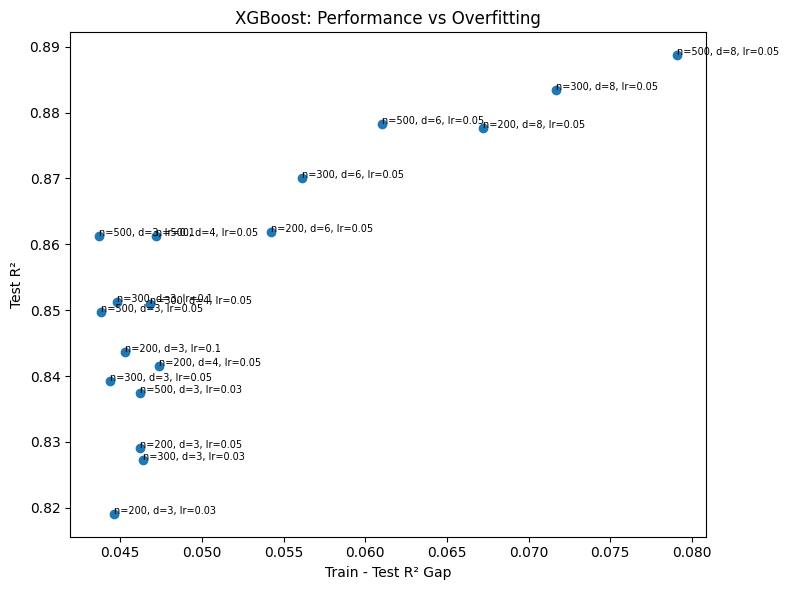

In [31]:
rows = [
{"n":200,"depth":3,"lr":0.03,"Train_R2":0.8637,"Test_R2":0.8191},
{"n":300,"depth":3,"lr":0.03,"Train_R2":0.8737,"Test_R2":0.8273},
{"n":500,"depth":3,"lr":0.03,"Train_R2":0.8837,"Test_R2":0.8375},

{"n":200,"depth":3,"lr":0.05,"Train_R2":0.8753,"Test_R2":0.8291},
{"n":300,"depth":3,"lr":0.05,"Train_R2":0.8836,"Test_R2":0.8392},
{"n":500,"depth":3,"lr":0.05,"Train_R2":0.8935,"Test_R2":0.8497},

{"n":200,"depth":3,"lr":0.1,"Train_R2":0.8890,"Test_R2":0.8437},
{"n":300,"depth":3,"lr":0.1,"Train_R2":0.8960,"Test_R2":0.8512},
{"n":500,"depth":3,"lr":0.1,"Train_R2":0.9050,"Test_R2":0.8613},

{"n":200,"depth":4,"lr":0.05,"Train_R2":0.8890,"Test_R2":0.8416},
{"n":300,"depth":4,"lr":0.05,"Train_R2":0.8978,"Test_R2":0.8510},
{"n":500,"depth":4,"lr":0.05,"Train_R2":0.9084,"Test_R2":0.8612},

{"n":200,"depth":6,"lr":0.05,"Train_R2":0.9161,"Test_R2":0.8619},
{"n":300,"depth":6,"lr":0.05,"Train_R2":0.9261,"Test_R2":0.8700},
{"n":500,"depth":6,"lr":0.05,"Train_R2":0.9393,"Test_R2":0.8783},

{"n":200,"depth":8,"lr":0.05,"Train_R2":0.9448,"Test_R2":0.8776},
{"n":300,"depth":8,"lr":0.05,"Train_R2":0.9551,"Test_R2":0.8834},
{"n":500,"depth":8,"lr":0.05,"Train_R2":0.9678,"Test_R2":0.8887},
]

df = pd.DataFrame(rows)

# gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

print(df.round(4))

plt.figure(figsize=(8,6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}, lr={row['lr']}",
        (row["Gap"], row["Test_R2"]),
        fontsize=7
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("XGBoost: Performance vs Overfitting")

plt.tight_layout()
plt.show()

The gap is actually lower than what rf does. After tuning, XGBoost outperforms Random Forest. The best model could be depth=6, 300 trees, and learning rate 0.05 with $R^2$ = 0.87.

# SHAP Analysis

In [27]:
import shap
import matplotlib.pyplot as plt

/Users/jenny/Desktop/IDX Exchange Intership/California-House-Price-Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
import xgboost as xgb

best_xgb = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_xgb, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


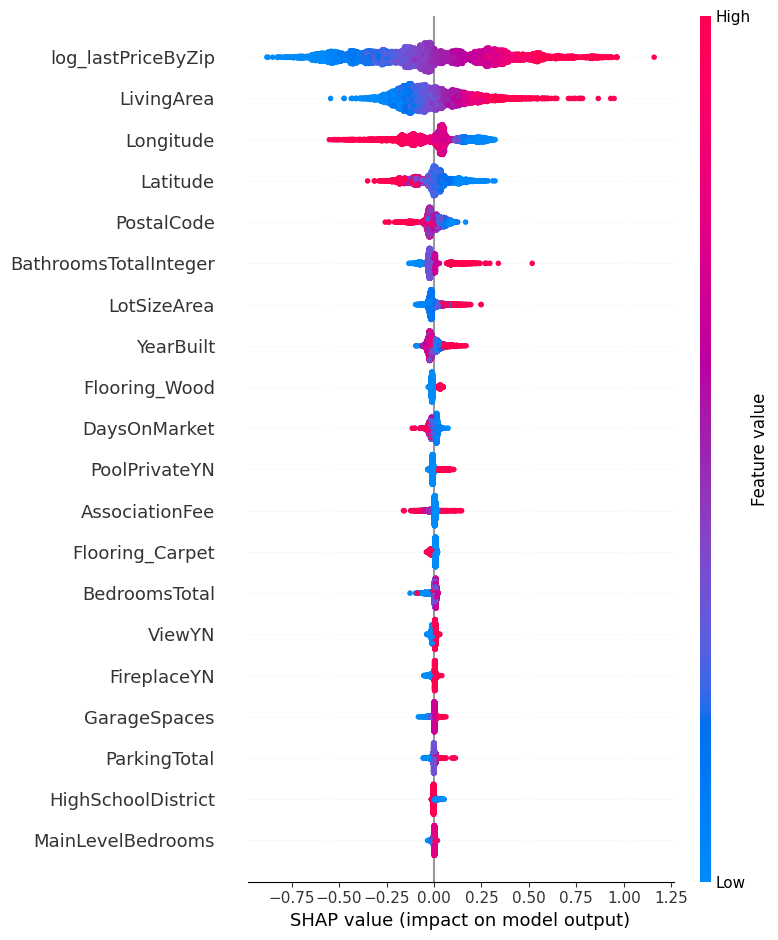

In [33]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_xgb)

shap.summary_plot(shap_values, X_test_xgb)